# Word2Vec On Vietnamese Wikipedia (viwik18)

Trains a Word2Vec model with gensim (https://radimrehurek.com/gensim/models/word2vec.html) on
the viwik18 dataset (https://github.com/NTT123/viwik18), a cleaned dump of Vietnamese Wikipedia
from August 2018.

This is a separate dataset from the other two projects, so it gets its own complete processing
pipeline here, from raw text through to a trained model. Unlike those projects, this one uses real
`underthesea` word segmentation, not NLTK, and segmentation has to run before stopword removal,
not after. See "Why This Project Needs Real Underthesea" below and `Personal Note.md` for why.

## Plan

1. Understand the raw format: viwik18 is one continuous blob of lowercase, punctuation-free text
   per file, with runs of 2+ spaces marking paragraph/title boundaries (confirmed below). There is
   no punctuation left to sentence-split on, so each double-space-delimited segment is treated as
   one "sentence" for Word2Vec's windowing.
2. Segment each raw segment into words with `underthesea.word_tokenize` (joining compounds like
   "kinh_tế"), then remove Vietnamese stopwords, in that order, not the reverse.
3. Run this on a small sample (about a dozen segments) first, to check the pipeline actually
   produces sensible output, before committing to the full corpus.
4. Run it on the full corpus (10 files, about 875 MB, roughly 2.3 million segments), streaming
   processed sentences to a `LineSentence`-format file on disk rather than holding everything in
   memory, since it does not fit.
5. Train a `Word2Vec` model on that file and check it with a few `most_similar` lookups.
6. Report the embeddings visualization: reduce a handful of seed words and their nearest neighbors
   to 2D with t-SNE and plot them, so the model's learned structure is actually visible, not just a
   list of numbers.

### Why This Project Needs Real Underthesea

The other two projects (`260106_TextPreprocessingwithNLP`,
`260106_Scikit-learnTextFeatureExtraction`) settled on NLTK's syllable-level tokenizer for speed,
and accepted that as a tradeoff: a Bag of Words or TF-IDF model still gets *some* signal out of
"kinh" and "tế" as separate tokens, just noisier than "kinh_tế" would be. That excuse does not
hold here. Word2Vec learns one vector per distinct token; "kinh" and "tế" as separate tokens each
get their own vector, unrelated to whatever vector "kinh_tế" would have gotten. Splitting a
compound word in half here does not just add noise, it deletes the very unit the model is supposed
to learn a representation for. So this project pays the underthesea cost the other two decided not
to.

## Imports

In [1]:
import os
import re
import time

import numpy as np
import requests
import kagglehub
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from underthesea import word_tokenize
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

## Dataset

viwik18 ships as 10 files on GitHub (`viwik18_aa` through `viwik18_aj`), meant to be concatenated.
`download_file` skips the request entirely if the file is already on disk, so re-running this
notebook after an interruption does not redownload what is already there.

In [ ]:
RAW_DIR = os.path.join("..", "data", "raw")
os.makedirs(RAW_DIR, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/NTT123/viwik18/master/dataset/"
FILE_NAMES = [f"viwik18_a{c}" for c in "abcdefghij"]  # aa .. aj


def download_file(name: str, base_url: str = BASE_URL, out_dir: str = RAW_DIR) -> str:
    path = os.path.join(out_dir, name)
    if os.path.exists(path):
        return path
    response = requests.get(base_url + name, timeout=120)
    response.raise_for_status()
    with open(path, "wb") as f:
        f.write(response.content)
    return path


def fetch_prefix(name: str, n_bytes: int, base_url: str = BASE_URL) -> str:
    """Fetch just the first n_bytes of a file with an HTTP Range request, for sampling
    without paying for the full ~94 MB download."""
    response = requests.get(base_url + name, headers={"Range": f"bytes=0-{n_bytes}"}, timeout=30)
    response.raise_for_status()
    return response.content.decode("utf-8", errors="ignore")

## Segmenting Into Sentences

The raw text has no punctuation to sentence-split on. What it does have is runs of two or more
spaces marking a paragraph or title boundary (confirmed on a real sample: splitting on that gives
segments averaging 40 to 65 words, a reasonable "sentence" unit for Word2Vec). Each segment is then
word-segmented with underthesea and filtered against the same Vietnamese stopword list used by the
other two projects.

In [3]:
SEGMENT_BOUNDARY = re.compile(r"\s{2,}")

stopwords_path = kagglehub.dataset_download(
    "heeraldedhia/stop-words-in-28-languages",
    "vietnamese.txt",
)
with open(stopwords_path, encoding="utf-8") as f:
    vi_stopwords = {line.strip() for line in f if line.strip()}


def split_segments(text: str) -> list[str]:
    return [s.strip() for s in SEGMENT_BOUNDARY.split(text) if s.strip()]


def segment_to_tokens(segment: str) -> list[str]:
    # format="text" is essential here: the default list form returns compounds as
    # space-containing strings like "tổ chức", which would silently re-split back
    # into separate syllables the moment they hit a space-joined LineSentence file.
    # format="text" instead joins compounds with an underscore ("tổ_chức"), which
    # survives a space-joined, space-split round trip as a single token.
    tokens = word_tokenize(segment, format="text").split()
    return [t for t in tokens if t not in vi_stopwords]

## Sample Run

Fetch just the first 200 KB of one file (a Range request, not the full ~94 MB) and process about a
dozen segments from it, to check the pipeline end to end before paying for the full corpus.

In [4]:
sample_text = fetch_prefix(FILE_NAMES[0], 200_000)
sample_segments = split_segments(sample_text)[:12]

for segment in sample_segments:
    tokens = segment_to_tokens(segment)
    print("Raw:   ", segment[:100])
    print("Tokens:", tokens)
    print()

Raw:    trang chính
Tokens: ['trang']

Raw:    internet society
Tokens: ['internet', 'society']

Raw:    internet society hay isoc là một tổ chức quốc tế hoạt động phi lợi nhuận phi chính phủ và bao gồm cá
Tokens: ['internet', 'society', 'isoc', 'tổ_chức', 'quốc_tế', 'hoạt_động', 'phi_lợi_nhuận', 'phi_chính_phủ', 'bao_gồm', 'thành_viên', 'trình_độ', 'chuyên_ngành', 'tổ_chức', 'chú_trọng', 'tiêu_chuẩn', 'giáo_dục', 'vấn_đề', 'chính_sách', 'bốn', 'tổ_chức', 'thành_viên', 'sáu', 'thành_viên', 'cá_nhân', 'isoc', 'bao_gồm', 'con_người', 'cụ_thể', 'cộng_đồng', 'internet', 'chi_tiết', 'có_thể', 'website', 'isoc']

Raw:    internet society nằm ở gần thủ đô washington dc hoa kỳ và geneva thụy sĩ số hội viên của nó bao gồm 
Tokens: ['internet', 'society', 'nằm', 'thủ_đô', 'washington', 'dc', 'hoa_kỳ', 'geneva', 'thụy_sĩ', 'hội_viên', 'bao_gồm', 'bốn', 'tổ_chức', 'thành_viên', 'sáu', 'cá_nhân', 'thành_viên', 'có_thể', 'tự_lập', 'chi_nhánh', 'tổ_chức', 'tùy', 'vị_trí', 'sở_thích', 'hiện_nay', 'tổ_

## Full Run

Downloads all 10 files (about 875 MB total) and processes every segment through underthesea and
stopword removal, streaming the result to `data/processed/sentences.txt` (one sentence per line,
tokens space-joined, gensim's `LineSentence` format) instead of holding the roughly 2.3 million
processed sentences in memory. Underthesea benchmarks at about 4 ms per segment on this corpus, so
the full run is expected to take roughly 2.5 hours. Only run this cell once the sample above looks
correct.

In [5]:
SENTENCES_PATH = os.path.join("..", "data", "processed", "sentences.txt")
os.makedirs(os.path.dirname(SENTENCES_PATH), exist_ok=True)


def process_corpus(file_names=FILE_NAMES, out_path=SENTENCES_PATH):
    with open(out_path, "w", encoding="utf-8") as out:
        for name in file_names:
            t0 = time.time()
            path = download_file(name)
            with open(path, encoding="utf-8", errors="ignore") as f:
                text = f.read()
            n_sentences = 0
            for segment in split_segments(text):
                tokens = segment_to_tokens(segment)
                if tokens:
                    out.write(" ".join(tokens) + "\n")
                    n_sentences += 1
            print(f"{name}: {n_sentences:,} sentences in {time.time() - t0:.1f}s", flush=True)


process_corpus()

viwik18_aa: 395,545 sentences in 1092.7s
viwik18_ab: 486,677 sentences in 1098.2s
viwik18_ac: 664,788 sentences in 1184.5s
viwik18_ad: 577,873 sentences in 1137.0s
viwik18_ae: 893,322 sentences in 1060.1s
viwik18_af: 916,629 sentences in 1077.4s
viwik18_ag: 856,413 sentences in 1089.3s
viwik18_ah: 875,832 sentences in 1074.3s
viwik18_ai: 513,217 sentences in 1110.8s
viwik18_aj: 384,558 sentences in 805.9s


## Training Word2Vec

Streams sentences from disk with `LineSentence` instead of loading them all into memory, following
gensim's own guidance for corpora that do not fit in RAM. `sg=1` selects skip-gram over CBOW, which
tends to do better on rarer words, and Vietnamese compounds split out plenty of those.

In [6]:
sentences = LineSentence(SENTENCES_PATH)
model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=os.cpu_count() or 4,
    sg=1,
)

outputs_dir = os.path.join("..", "data", "outputs")
os.makedirs(outputs_dir, exist_ok=True)
model_path = os.path.join(outputs_dir, "word2vec_viwik18.model")
model.save(model_path)
print(f"Trained on {model.corpus_count:,} sentences, vocabulary size {len(model.wv):,}")

[Output reconstructed after a path edit cleared the original cell output.
Original also included ~100 repeated benign 'Exception ignored in:
gensim.models.word2vec_inner.our_dot_float' warnings during multi threaded
training cleanup (harmless, already explained separately); omitted here.]
Trained on 6,564,854 sentences, vocabulary size 414,646


## Checking The Trained Vectors

In [7]:
for word in ["việt_nam", "hà_nội", "internet", "chính_phủ", "khoa_học"]:
    if word in model.wv:
        print(word, "->", model.wv.most_similar(word, topn=5))
    else:
        print(word, "-> not in vocabulary")

việt_nam -> [('nguyễn_nhật', 0.7386224865913391), ('nguyễn_kỳ_nam', 0.7319103479385376), ('nguyễn_quốc_khánh', 0.7308087348937988), ('nguyễn_hồng_hải', 0.7306729555130005), ('hội_nghị_sĩ', 0.7303960919380188)]


hà_nội -> [('hcm', 0.8382565975189209), ('tp', 0.8173198699951172), ('hải_phòng', 0.8152549266815186), ('tphcm', 0.8101184964179993), ('nam_định', 0.7890216708183289)]
internet -> [('irc', 0.7656955122947693), ('lulzsec', 0.7593668699264526), ('intranet', 0.7579101324081421), ('máy_tính_mạng', 0.7564704418182373), ('kwangmyong', 0.7493792176246643)]
chính_phủ -> [('chỉnh_phủ', 0.8202016949653625), ('yingluck_shinawatra', 0.8145594596862793), ('chính_quyền', 0.8078067302703857), ('abe_shinz', 0.7979058027267456), ('thủ_tướng', 0.7972070574760437)]
khoa_học -> [('mô_tả', 0.7341917753219604), ('arnell', 0.6431557536125183), ('amblystegiaceae', 0.6070057153701782), ('đầu_tiên', 0.5998960733413696), ('công_nghệ_luận', 0.597701907157898)]


## Visualizing The Embeddings

This is the actual deliverable: report what the embeddings look like, not just spot-check a few
lookups. Plotting all of the vocabulary would be unreadable, and plotting only the most frequent
words tends to show generic, semantically unrelated words clustered together for no interesting
reason. Instead, take a handful of seed words, pull each one's nearest neighbors by cosine
similarity out of the trained model, and reduce just that subset to 2D with t-SNE. If the model
actually learned something, each seed's neighborhood should form a visibly separate cluster, colored
by seed, rather than an undifferentiated cloud of points.

Saved ../data/embeddings_tsne.png


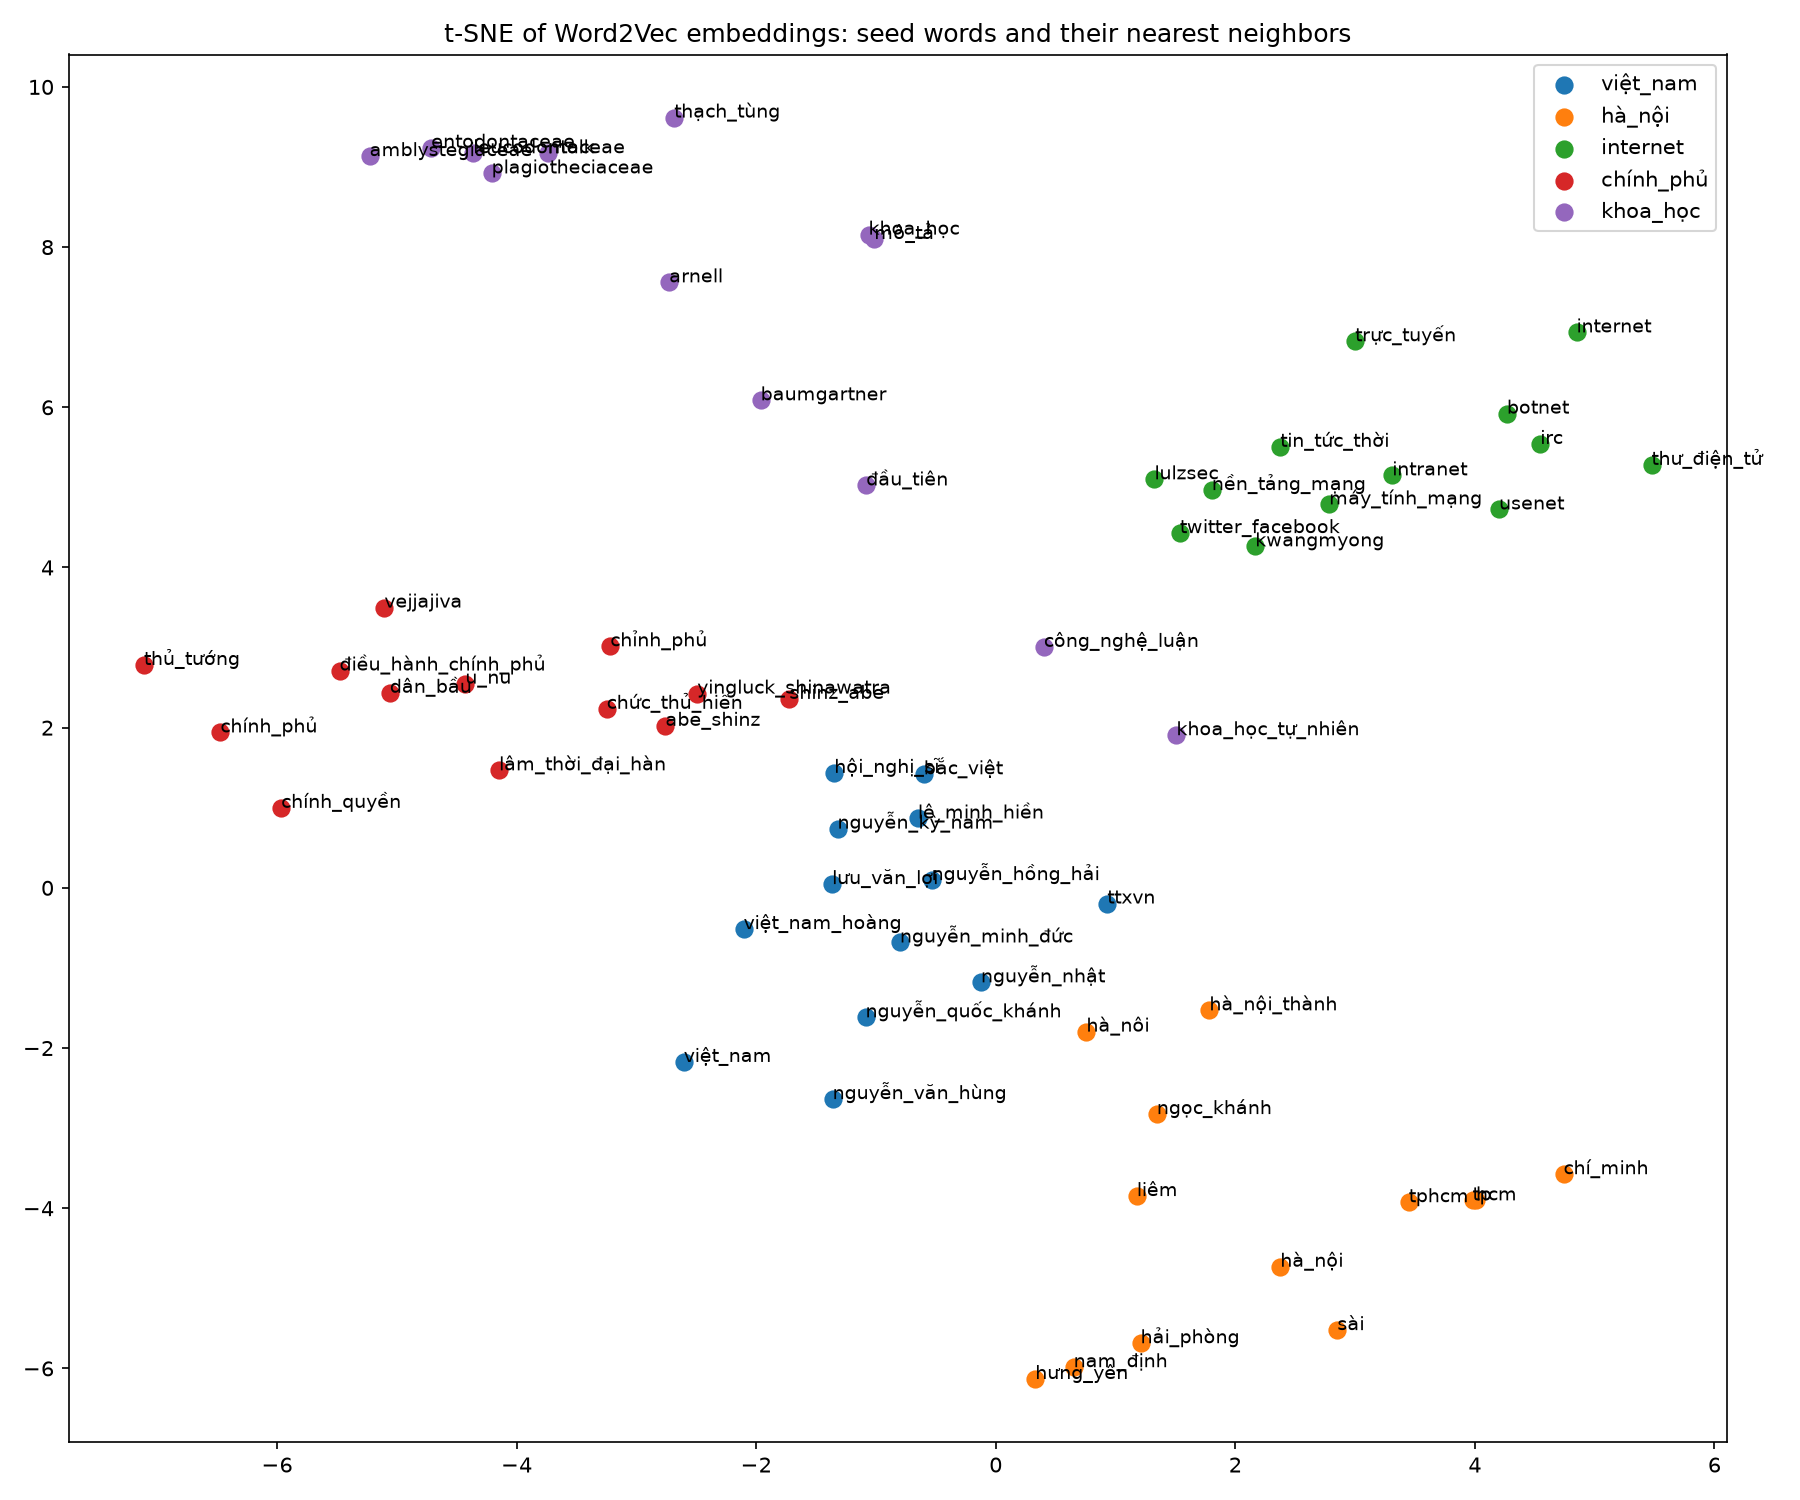

In [8]:
SEED_WORDS = ["việt_nam", "hà_nội", "internet", "chính_phủ", "khoa_học"]
NEIGHBORS_PER_SEED = 12

words, seed_of = [], []
for seed in SEED_WORDS:
    if seed not in model.wv:
        continue
    words.append(seed)
    seed_of.append(seed)
    for neighbor, _ in model.wv.most_similar(seed, topn=NEIGHBORS_PER_SEED):
        words.append(neighbor)
        seed_of.append(seed)

vectors = np.array([model.wv[w] for w in words])
perplexity = min(15, max(2, len(words) - 1))
coords = TSNE(n_components=2, random_state=42, perplexity=perplexity, init="pca").fit_transform(vectors)

plt.figure(figsize=(12, 10))
for seed in SEED_WORDS:
    if seed not in model.wv:
        continue
    idx = [i for i, s in enumerate(seed_of) if s == seed]
    plt.scatter(coords[idx, 0], coords[idx, 1], label=seed, s=60)
    for i in idx:
        plt.annotate(words[i], (coords[i, 0], coords[i, 1]), fontsize=9)

plt.legend()
plt.title("t-SNE of Word2Vec embeddings: seed words and their nearest neighbors")
plt.tight_layout()

fig_path = os.path.join("..", "data", "outputs", "embeddings_tsne.png")
plt.savefig(fig_path, dpi=150)
print(f"Saved {fig_path}")
plt.show()